## Matching Concept Concatenate Aphasia + Controls


In [62]:
import pandas as pd

true_apahsia_df = pd.read_csv("../../data/data/Matching Concept Check - Aphasia - All.csv")
true_aphasia_controls_df = pd.read_csv("../../data/data/Matching Concept Check - Controls - All.csv")

predicted_aphasia_df = pd.read_csv("../../data/data/base_matching_mainconcept_aphasia_predicted_output.csv")
predicted_aphasia_controls_df = pd.read_csv("../../data/data/base_matching_mainconcept_aphasia_controls_predicted_output.csv")

# Combine by group
true_df = pd.concat([true_apahsia_df, true_aphasia_controls_df], ignore_index=True)
predicted_df = pd.concat([predicted_aphasia_df, predicted_aphasia_controls_df], ignore_index=True)






In [63]:
true_df.info()
predicted_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 982 entries, 0 to 981
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   participant              982 non-null    object 
 1   utterances               982 non-null    object 
 2   Ground Truth Matching?   982 non-null    bool   
 3   matching1                982 non-null    bool   
 4   matching2                982 non-null    bool   
 5   matching3                982 non-null    bool   
 6   Disagree Flag            494 non-null    object 
 7   Unnamed: 7               0 non-null      float64
 8   Unnamed: 8               1 non-null      float64
 9   157                      0 non-null      float64
 10  Disagreement?            488 non-null    object 
dtypes: bool(4), float64(3), object(4)
memory usage: 57.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 982 entries, 0 to 981
Data columns (total 7 columns):
 #   Column                

In [64]:
# TRUE DF cleanup
true_df = true_df[['participant', 'utterances', 'Ground Truth Matching? ']]

# rename 'utterances' to match predicted's column
true_df = true_df.rename(columns={'utterances': 'utterance'})
# PREDICTED DF cleanup
pred_df = predicted_df[['utterance', 'is_main_concept']]
pred_df = pred_df.rename(columns={'is_main_concept': 'predicted matching'})

combined_df = true_df.merge(
    pred_df,
    on='utterance',
    how='inner'  # inner ensures only matching utterances appear
)

In [65]:
combined_df = combined_df.loc[:, ~combined_df.columns.str.contains('^Unnamed')]
combined_df = combined_df.dropna(axis=1, how='all')  # columns with all NaN

In [66]:
combined_df.head()

,participant,utterance,Ground Truth Matching?,predicted matching
0,williamson10a,"Uh, there's a lady who has 3 daughters, and , ...",True,True
1,williamson10a,"and they, she received an invitation to attend...",True,True
2,williamson10a,"But the,.",False,False
3,williamson10a,"but the, the, the, the 3 daughter thinks they'...",True,True
4,williamson10a,"but his two daughters go,.",True,True


In [67]:
combined_df.to_csv("base_test_matching_aphasia_controls.csv", index=False)

[[187 167]
 [ 46 650]]


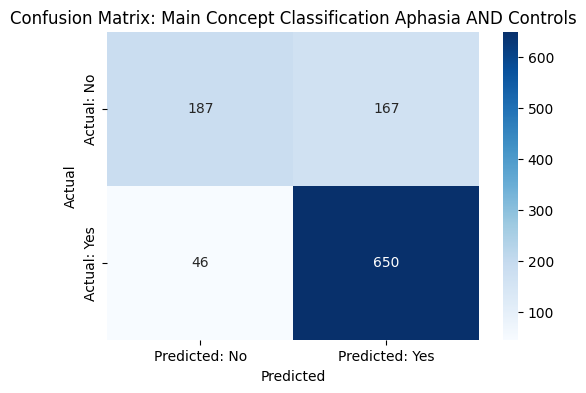

              precision    recall  f1-score   support

       False       0.80      0.53      0.64       354
        True       0.80      0.93      0.86       696

    accuracy                           0.80      1050
   macro avg       0.80      0.73      0.75      1050
weighted avg       0.80      0.80      0.78      1050



In [68]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = combined_df['Ground Truth Matching? ']
y_pred = combined_df['predicted matching']

cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title("Confusion Matrix: Main Concept Classification Aphasia AND Controls")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_true, y_pred))

In [ ]:
y_true = combined_df['Ground Truth Matching? ']
y_pred = combined_df['predicted matching']        # binary (0/1)       # continuous score
# ROC–AUC

# F1
f1 = f1_score(y_true, y_pred)

print(f"F1 score: {f1:.3f}")

print("\nClassification report:")
print(classification_report(y_true, y_pred))


F1 score: 0.859

Classification report:
              precision    recall  f1-score   support

       False       0.80      0.53      0.64       354
        True       0.80      0.93      0.86       696

    accuracy                           0.80      1050
   macro avg       0.80      0.73      0.75      1050
weighted avg       0.80      0.80      0.78      1050



In [47]:
incorrect_df = combined_df[combined_df['Ground Truth Matching? '] != combined_df['predicted matching']]
incorrect_df.to_csv("base_mainconcept_incorrect_aphasia_controls_cases.csv", index=False)

## Matching Concept Concatenate Dementia + Controls

In [48]:
import pandas as pd

true_dementia_df = pd.read_csv("../../data/data/Matching Concept Check - Dementia - All.csv")
true_dementia_controls_df = pd.read_csv("../../data/data/Matching Concept Check - Controls - All.csv")

predicted_dementia_df = pd.read_csv("../../data/data/base_matching_mainconcept_dementia_predicted_output.csv")
predicted_dementia_controls_df = pd.read_csv("../../data/data/base_matching_mainconcept_dementia_controls_predicted_output.csv")

# Combine by group
true_df = pd.concat([true_dementia_df, true_dementia_controls_df], ignore_index=True)
predicted_df = pd.concat([predicted_dementia_df, predicted_dementia_controls_df], ignore_index=True)




In [49]:
true_df.info()
predicted_df.info()

# TRUE DF cleanup
true_df = true_df[['participant', 'utterances', 'Ground Truth Matching? ']]

# rename 'utterances' to match predicted's column
true_df = true_df.rename(columns={'utterances': 'utterance'})
# PREDICTED DF cleanup
pred_df = predicted_df[['utterance', 'is_main_concept']]
pred_df = pred_df.rename(columns={'is_main_concept': 'predicted matching'})

combined_df = true_df.merge(
    pred_df,
    on='utterance',
    how='inner'  # inner ensures only matching utterances appear
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   participant              973 non-null    object 
 1   utterances               972 non-null    object 
 2   Ground Truth Matching?   972 non-null    object 
 3   Matching 1               484 non-null    object 
 4   Matching2                484 non-null    object 
 5   Matching3                484 non-null    object 
 6   Disagree?                484 non-null    object 
 7   Unnamed: 7               0 non-null      float64
 8   Unnamed: 8               2 non-null      float64
 9   matching1                488 non-null    object 
 10  matching2                488 non-null    object 
 11  matching3                488 non-null    object 
 12  Disagreement?            488 non-null    object 
dtypes: float64(2), object(11)
memory usage: 98.9+ KB
<class 'pandas.core.frame.DataF

In [50]:
combined_df = combined_df.loc[:, ~combined_df.columns.str.contains('^Unnamed')]
combined_df = combined_df.dropna(axis=1, how='all')  # columns with all NaN
combined_df.head()

,participant,utterance,Ground Truth Matching?,predicted matching
0,20-2,"At any rate, Cinderella was working in a in a ...",True,True
1,20-2,"OK, anyway, she, um.",False,True
2,20-2,"Yeah, OK, we'll go from there.",False,False
3,20-2,"Anyway, there's a fair uh fairy godmother who,...",True,True
4,20-2,and who provides her with the opportunity to g...,True,True


In [51]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1026 entries, 0 to 1025
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   participant              1026 non-null   object
 1   utterance                1026 non-null   object
 2   Ground Truth Matching?   1026 non-null   object
 3   predicted matching       1026 non-null   bool  
dtypes: bool(1), object(3)
memory usage: 25.2+ KB


In [52]:
import numpy as np

# Start from your dataframe
df = combined_df.copy()

# Normalize to lowercase stripped strings
gt_raw = df['Ground Truth Matching? '].astype(str).str.strip().str.lower()

# Map common truthy/falsey strings to bool
mapping = {
    'True': True,
    'False': False,
    'true': True,
    'false': False,
    'yes': True,
    'no': False,
    '1': True,
    '0': False
}

df['gt_bool'] = gt_raw.map(mapping)

# Optional: see if anything didn't map
print("Unmapped values in Ground Truth Matching?:")
print(sorted(set(gt_raw[df['gt_bool'].isna()])))

Unmapped values in Ground Truth Matching?:
[]


In [53]:
combined_df.to_csv("base_test_matching_dementia_controls.csv", index=False)
combined_df.columns = combined_df.columns.str.strip()


In [54]:
# Clean column names (optional but safe)
combined_df.columns = combined_df.columns.str.strip()

# Convert Ground Truth Matching? column to boolean
combined_df['Ground Truth Matching?'] = (
    combined_df['Ground Truth Matching?']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({'true': True, 'false': False, '1': True, '0': False, 'yes': True, 'no': False})
)


[[141  41]
 [ 56 788]]


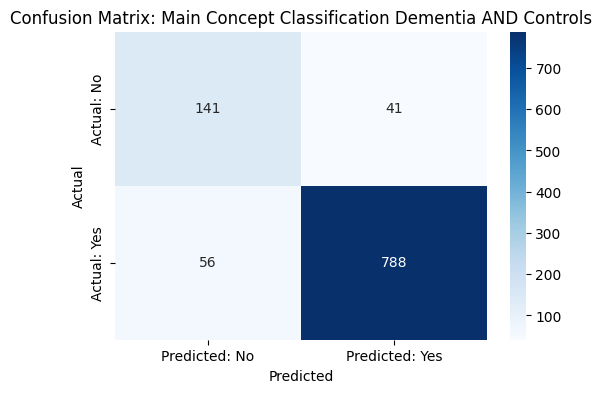

              precision    recall  f1-score   support

       False       0.72      0.77      0.74       182
        True       0.95      0.93      0.94       844

    accuracy                           0.91      1026
   macro avg       0.83      0.85      0.84      1026
weighted avg       0.91      0.91      0.91      1026



In [55]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = combined_df['Ground Truth Matching?']
y_pred = combined_df['predicted matching']

cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title("Confusion Matrix: Main Concept Classification Dementia AND Controls")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_true, y_pred))


[[141  41]
 [ 56 788]]


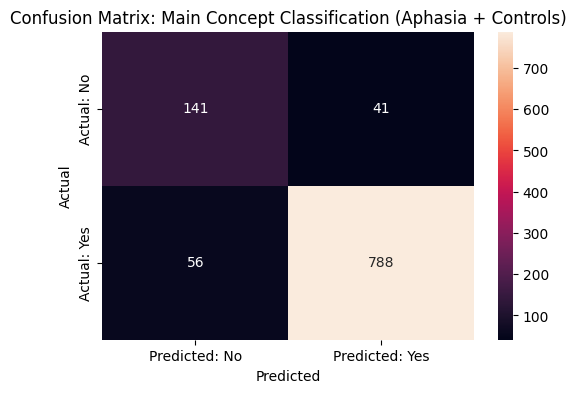

              precision    recall  f1-score   support

       False       0.72      0.77      0.74       182
        True       0.95      0.93      0.94       844

    accuracy                           0.91      1026
   macro avg       0.83      0.85      0.84      1026
weighted avg       0.91      0.91      0.91      1026



In [56]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Keep only rows where both GT and prediction are not NaN
mask = df['gt_bool'].notna() & df['predicted matching'].notna()
clean_df = df[mask]

y_true = clean_df['gt_bool']
y_pred = clean_df['predicted matching'].astype(bool)

# Force label order [False, True] so it's consistent
cm = confusion_matrix(y_true, y_pred, labels=[False, True])
print(cm)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=['Predicted: No', 'Predicted: Yes'],
    yticklabels=['Actual: No', 'Actual: Yes']
)
plt.title("Confusion Matrix: Main Concept Classification (Aphasia + Controls)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_true, y_pred))


[[141  41]
 [ 56 788]]


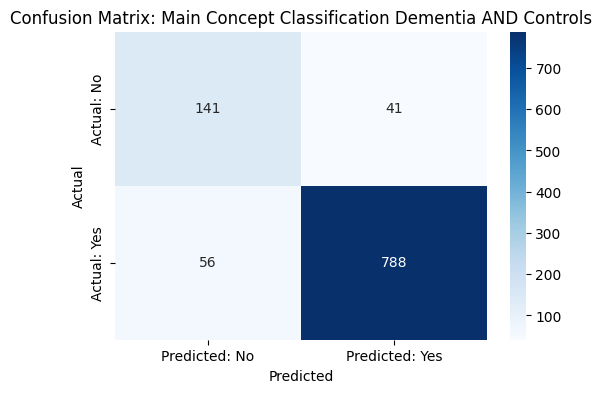

              precision    recall  f1-score   support

       False       0.72      0.77      0.74       182
        True       0.95      0.93      0.94       844

    accuracy                           0.91      1026
   macro avg       0.83      0.85      0.84      1026
weighted avg       0.91      0.91      0.91      1026



In [57]:
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

y_true = combined_df['Ground Truth Matching?']
y_pred = combined_df['predicted matching']

cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title("Confusion Matrix: Main Concept Classification Dementia AND Controls")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_true, y_pred))

In [60]:
y_true = combined_df['Ground Truth Matching?']
y_pred = combined_df['predicted matching']        # binary (0/1)       # continuous score
# ROC–AUC

# F1
f1 = f1_score(y_true, y_pred)

print(f"F1 score: {f1:.3f}")

print("\nClassification report:")
print(classification_report(y_true, y_pred))

F1 score: 0.942

Classification report:
              precision    recall  f1-score   support

       False       0.72      0.77      0.74       182
        True       0.95      0.93      0.94       844

    accuracy                           0.91      1026
   macro avg       0.83      0.85      0.84      1026
weighted avg       0.91      0.91      0.91      1026



In [36]:
incorrect_df = combined_df[combined_df['Ground Truth Matching?'] != combined_df['predicted matching']]
incorrect_df.to_csv("base_mainconcept_incorrect_dementia_controls_cases.csv", index=False)